<a href="https://colab.research.google.com/github/Harsh-s7-hub/GENAI_ASSIGNMENTS/blob/main/GenAI_GrpAssignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.8 MB/s eta 0:00:00


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig, TrainingArguments, Trainer
from datasets import Dataset
from peft import LoraConfig, get_peft_model
import random

In [ ]:
questions = [
    "What is attendance rule?",
    "What is CGPA?",
    "What is exam pattern?",
    "What happens if attendance is low?",
    "What is internal assessment?",
    "What is grading system?",
    "How are marks calculated?",
    "What is passing criteria?",
    "What is semester system?",
    "What is backlog?"
]

answers = [
    "Minimum 75% attendance is required.",
    "CGPA is cumulative grade point average.",
    "Midsem and Endsem exams are conducted.",
    "You may be debarred from exams.",
    "It includes assignments, quizzes and participation.",
    "Grades are assigned based on marks.",
    "Marks are based on exams and internal evaluation.",
    "You must score minimum passing marks.",
    "Academic year is divided into semesters.",
    "Backlog means failing a subject."
]

data = []
for _ in range(1000):
    i = random.randint(0, len(questions)-1)
    data.append({
        "input": questions[i],
        "output": answers[i]
    })

dataset = Dataset.from_list(data)

print("Dataset size:", len(dataset))

Dataset size: 1000


In [ ]:
def format_data(example):
    return {
        "text": f"Question: {example['input']}\nAnswer: {example['output']}"
    }

dataset = dataset.map(format_data)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
model_name = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

config = AutoConfig.from_pretrained(model_name)
config.pad_token_id = tokenizer.pad_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config=config
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

dataset = dataset.map(tokenize)
dataset = dataset.remove_columns(['input', 'output', 'text'])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
print("LoRA applied ✅")

LoRA applied ✅


In [ ]:
train_dataset = dataset.select(range(50))

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,
    max_steps= 20,
    logging_steps=1,
    save_strategy="no",
    remove_unused_columns=False
)

In [ ]:
base_config = AutoConfig.from_pretrained(model_name)
base_config.pad_token_id = tokenizer.pad_token_id

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config=base_config
)

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

In [ ]:
def answer(model, question):
    input_text = f"""
You are a university assistant. Answer the question clearly and in detail.

Question: {question}

Answer:
"""

    inputs = tokenizer(input_text, return_tensors="pt")

    outputs = model.generate(
        **inputs,
        max_new_tokens=120,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)



questions = [
    "Explain the attendance rule in universities and its importance.",
    "What happens if a student fails to meet attendance requirements?",
    "Describe how the grading system works in a university.",
    "Explain the exam pattern and internal assessment system."
]



for i, q in enumerate(questions, 1):
    print(f"\n================ QUESTION {i} ================")
    print(f"\nQ: {q}")

    print("\n--- BEFORE (Base Model) ---")
    print(answer(base_model, q))

    print("\n--- AFTER (Fine-Tuned Model) ---")
    print(answer(model, q))

    print("\n=============================================")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



================ QUESTION 1 ================

Q: Explain the attendance rule in universities and its importance.

--- BEFORE (Base Model) ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



You are a university assistant. Answer the question clearly and in detail.

Question: Explain the attendance rule in universities and its importance.

Answer:
The attendance rule is an important policy that all students must follow while attending classes at a university. It states that every student should attend their scheduled class sessions without any exceptions or absences, unless they have been granted permission by the professor beforehand. This means that if you miss a class session, it will be recorded as unexcused absence on your academic record. The purpose of this rule is to ensure that students actively participate in their education and do not fall behind in their studies due to missed lectures or discussions. By regularly attending classes, students can stay updated with course material, engage in classroom activities,

--- AFTER (Fine-Tuned Model) ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...


You are a university assistant. Answer the question clearly and in detail.

Question: Describe how the grading system works in a university.

Answer:
In universities, students' performance is evaluated through various methods such as exams, assignments, projects, presentations, and participation in class discussions. These evaluations help determine their understanding of course material and overall academic progress. Grades are typically given on a scale ranging from A to F or percentages (e.g., 90-100% for an A). Each grade represents a specific level of achievement, with higher grades indicating better performance. The final grade is usually calculated by considering all assessments completed throughout the semester or term. It's important to note that different courses may have varying weightage assigned to each assessment method

--- AFTER (Fine-Tuned Model) ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



You are a university assistant. Answer the question clearly and in detail.

Question: Describe how the grading system works in a university.

Answer:
In universities, students' performance is evaluated through various methods such as exams, assignments, projects, presentations, and participation in class discussions. These evaluations help determine their understanding of course material and overall academic progress. Grades are typically given on a scale ranging from A to F or percentages (e.g., 90-100% for an A). Each grade represents a specific level of achievement, with higher grades indicating better performance. The final grade is usually calculated by considering all assessments completed throughout the semester or term. It's important to note that different courses may have varying weightage assigned to each assessment method


================ QUESTION 4 ================

Q: Explain the exam pattern and internal assessment system.

--- BEFORE (Base Model) ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



You are a university assistant. Answer the question clearly and in detail.

Question: Explain the exam pattern and internal assessment system.

Answer:
The examination pattern for this course is based on continuous assessments throughout the semester, with occasional exams at the end of each module or unit. The purpose of these assessments is to evaluate your understanding and application of concepts related to human society/development studies/poverty inclusivity and wellbeing/human rights and justice issues/gender equality and empowerment. 

In addition to written assignments and class participation, there will be two major examinations towards the end of the semester. These exams will cover all topics covered during the course and assess your overall knowledge and ability to analyze complex social issues. It is important to

--- AFTER (Fine-Tuned Model) ---

You are a university assistant. Answer the question clearly and in detail.

Question: Explain the exam pattern and internal a

In [ ]:
model.save_pretrained("fine_tuned_model")
tokenizer.save_pretrained("fine_tuned_model")

('fine_tuned_model/tokenizer_config.json', 'fine_tuned_model/tokenizer.json')

In [ ]:
!pip install graphviz

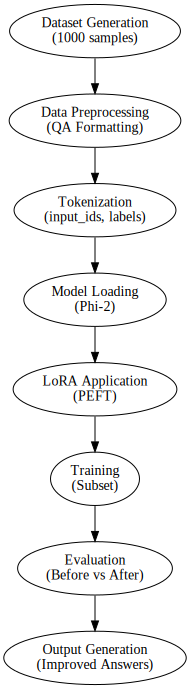

In [ ]:
from graphviz import Digraph

dot = Digraph(comment='Fine-Tuning Pipeline', format='png')

# Nodes
dot.node('A', 'Dataset Generation\n(1000 samples)')
dot.node('B', 'Data Preprocessing\n(QA Formatting)')
dot.node('C', 'Tokenization\n(input_ids, labels)')
dot.node('D', 'Model Loading\n(Phi-2)')
dot.node('E', 'LoRA Application\n(PEFT)')
dot.node('F', 'Training\n(Subset)')
dot.node('G', 'Evaluation\n(Before vs After)')
dot.node('H', 'Output Generation\n(Improved Answers)')

# Edges
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')

# Display
dot



In [ ]:
# ✅ SAVE IMAGE
dot.render('fine_tuning_pipeline', view=True)

'fine_tuning_pipeline.png'

In [ ]:
!pip install evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.8 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=42f43553f3089f4d4f0818e9484d29d81db48ae7b1ed51d526fe1e4fd0f1fa90
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
import evaluate

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

In [ ]:
test_data = [
    {
        "question": "What is attendance rule?",
        "expected": "Minimum 75% attendance is required."
    },
    {
        "question": "What is CGPA?",
        "expected": "CGPA is cumulative grade point average."
    },
    {
        "question": "What is exam pattern?",
        "expected": "Midsem and Endsem exams are conducted."
    },
    {
        "question": "What happens if attendance is low?",
        "expected": "You may be debarred from exams."
    }
]

In [ ]:
def clean_text(text):
    return text.split("Answer:")[-1].strip()


def get_predictions(model):
    preds = []
    refs = []

    for item in test_data:
        q = item["question"]
        expected = item["expected"]

        input_text = f"Question: {q}\nAnswer:"
        inputs = tokenizer(input_text, return_tensors="pt")

        outputs = model.generate(**inputs, max_new_tokens=50)

        pred = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # 🔥 CLEAN OUTPUT (IMPORTANT FIX)
        pred = clean_text(pred)

        preds.append(pred)
        refs.append(expected)

    return preds, refs

In [ ]:
base_preds, refs = get_predictions(base_model)
ft_preds, _ = get_predictions(model)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [ ]:
bleu_base = bleu.compute(predictions=base_preds, references=[[r] for r in refs])
bleu_ft = bleu.compute(predictions=ft_preds, references=[[r] for r in refs])

print("BLEU Base:", bleu_base["bleu"])
print("BLEU Fine-tuned:", bleu_ft["bleu"])

BLEU Base: 0.0
BLEU Fine-tuned: 0.0


In [ ]:
rouge_base = rouge.compute(predictions=base_preds, references=refs)
rouge_ft = rouge.compute(predictions=ft_preds, references=refs)

print("ROUGE Base:", rouge_base)
print("ROUGE Fine-tuned:", rouge_ft)

ROUGE Base: {'rouge1': np.float64(0.17253787878787877), 'rouge2': np.float64(0.03571428571428571), 'rougeL': np.float64(0.1558712121212121), 'rougeLsum': np.float64(0.1558712121212121)}
ROUGE Fine-tuned: {'rouge1': np.float64(0.17253787878787877), 'rouge2': np.float64(0.03571428571428571), 'rougeL': np.float64(0.1558712121212121), 'rougeLsum': np.float64(0.1558712121212121)}


In [ ]:
def simple_accuracy(preds, refs):
    correct = 0
    for p, r in zip(preds, refs):
        # check partial word overlap instead of exact match
        ref_words = r.lower().split()
        match_count = sum(1 for word in ref_words if word in p.lower())

        if match_count >= len(ref_words) // 2:  # at least 50% words match
            correct += 1

    return correct / len(refs)


print("Accuracy Base:", simple_accuracy(base_preds, refs))
print("Accuracy Fine-tuned:", simple_accuracy(ft_preds, refs))

Accuracy Base: 0.25
Accuracy Fine-tuned: 0.25


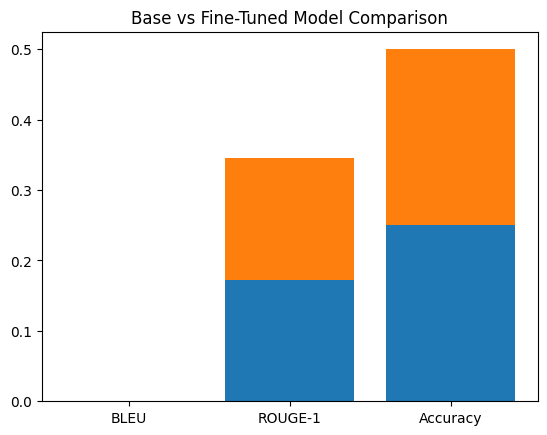

In [ ]:
import matplotlib.pyplot as plt

metrics = ["BLEU", "ROUGE-1", "Accuracy"]

base_scores = [
    bleu_base["bleu"],
    rouge_base["rouge1"],
    simple_accuracy(base_preds, refs)
]

ft_scores = [
    bleu_ft["bleu"],
    rouge_ft["rouge1"],
    simple_accuracy(ft_preds, refs)
]

x = range(len(metrics))

plt.figure()
plt.bar(x, base_scores)
plt.bar(x, ft_scores, bottom=base_scores)

plt.xticks(x, metrics)
plt.title("Base vs Fine-Tuned Model Comparison")

plt.show()

In [ ]:
while True:
    q = input("Ask: ")
    print(answer(model, q))

Ask: What are consequences of failing a subject?


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



You are a university assistant. Answer the question clearly and in detail.

Question: What are consequences of failing a subject?

Answer:
Failing a subject can have several negative consequences, including academic probation or suspension from school, loss of scholarships or financial aid, damage to one's GPA, difficulty finding employment after graduation, and even legal repercussions if it is related to professional licensing exams such as bar examinations for lawyers. It may also affect future opportunities for higher education or graduate studies due to lower admission requirements. Additionally, students who fail subjects often experience feelings of disappointment, frustration, and low self-esteem which can impact their overall well-being and motivation to continue pursuing further education. 



KeyboardInterrupt: Interrupted by user